In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


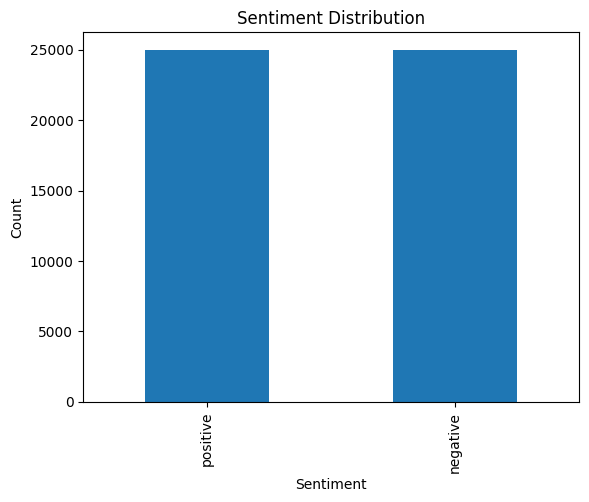

In [4]:
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [5]:
df.shape

(50000, 2)

In [6]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        # remove links
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'#', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) #This removes all punctuation marks from text.
    text = text.strip()                        # Removes extra spaces from beginning and end
    return text

df['review'] = df['review'].apply(clean_text)

In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['review_sentiment']=le.fit_transform(df['sentiment'])
df.drop('sentiment', axis=1, inplace=True)

In [10]:
df.head()

,review,review_sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production br br the filmin...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [11]:
pip install transformers 

Note: you may need to restart the kernel to use updated packages.


In [12]:
from transformers import AutoTokenizer,AutoModel

In [13]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"

In [14]:
tokenizer=AutoTokenizer.from_pretrained(model_name)
sbert=AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
encoded = tokenizer(
    list(df['review']),
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True
)

In [16]:
input_ids=encoded['input_ids']

In [17]:
input_ids[0]

[101,
 2028,
 1997,
 1996,
 2060,
 15814,
 2038,
 3855,
 2008,
 2044,
 3666,
 2074,
 11472,
 2792,
 2017,
 3363,
 2022,
 13322,
 2027,
 2024,
 2157,
 2004,
 2023,
 2003,
 3599,
 2054,
 3047,
 2007,
 2033,
 19892,
 7987,
 1996,
 2034,
 2518,
 2008,
 4930,
 2033,
 2055,
 11472,
 2001,
 2049,
 24083,
 1998,
 4895,
 10258,
 2378,
 8450,
 5019,
 1997,
 4808,
 2029,
 2275,
 1999,
 2157,
 2013,
 1996,
 2773,
 2175,
 3404,
 2033,
 2023,
 2003,
 2025,
 1037,
 2265,
 2005,
 1996,
 8143,
 18627,
 2030,
 5199,
 3593,
 2023,
 2265,
 8005,
 2053,
 17957,
 2007,
 12362,
 2000,
 5850,
 3348,
 2030,
 4808,
 2049,
 2003,
 13076,
 1999,
 1996,
 4438,
 2224,
 1997,
 1996,
 2773,
 19892,
 7987,
 2009,
 2003,
 2170,
 11472,
 2004,
 2008,
 2003,
 1996,
 8367,
 2445,
 2000,
 1996,
 17411,
 4555,
 3036,
 2110,
 7279,
 4221,
 12380,
 2854,
 2009,
 7679,
 3701,
 2006,
 14110,
 2103,
 2019,
 6388,
 2930,
 1997,
 1996,
 102]

In [18]:
attention_mask=encoded['attention_mask']

In [19]:
import torch
input_ids = torch.tensor(input_ids)
attention_mask = torch.tensor(attention_mask)

labels = torch.tensor(df['review_sentiment'].values)
labels

tensor([1, 1, 1,  ..., 0, 0, 0])

In [20]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(input_ids, attention_mask, labels)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# SBERT_BILSTM_RESIDUAL

In [21]:
import torch.nn as nn

class SBERT_BiLSTM_Residual(nn.Module):
    def __init__(self, hidden_dim=128, num_classes=3):
        super().__init__()

        self.sbert = sbert

        self.bilstm = nn.LSTM(
            input_size=384,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Residual block
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):

        # SBERT embeddings
        with torch.no_grad():   # freeze SBERT (important)
            outputs = self.sbert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        x = outputs.last_hidden_state  # (batch, seq_len, 384)

        # BiLSTM
        lstm_out, _ = self.bilstm(x)

        # Better than last step → mean pooling
        out = torch.mean(lstm_out, dim=1)

        # Residual connection
        res = out
        out = self.fc(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = out + res

        return self.classifier(out)

In [22]:
import torch

input_ids = torch.tensor(input_ids)
attention_mask = torch.tensor(attention_mask)
labels = torch.tensor(labels)

/tmp/ipykernel_57/1180488739.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(input_ids)
/tmp/ipykernel_57/1180488739.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(attention_mask)
/tmp/ipykernel_57/1180488739.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels)


In [23]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(input_ids, attention_mask, labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [24]:
print(torch.cuda.is_available())
device = torch.device("cpu")

True


In [25]:

model = SBERT_BiLSTM_Residual().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [26]:
!pip install tqdm

In [27]:
# checkpoint = torch.load("/kaggle/working/checkpoint.pth", map_location=device)

# model.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# start_epoch = checkpoint["epoch"] + 1

# print("Last completed epoch:", checkpoint["epoch"] + 1)
# print("Resuming from epoch:", start_epoch + 1)

In [28]:
from tqdm.auto import tqdm

for epoch in range(7):
    model.train()
    total_loss = 0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/3 Training",
        total=len(train_loader)
    )

    for batch in train_progress:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        train_progress.set_postfix(loss=loss.item())

    print(f"Epoch {epoch + 1}, Training Loss: {total_loss:.4f}")

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    val_progress = tqdm(
        val_loader,
        desc=f"Epoch {epoch + 1}/3 Validation",
        total=len(val_loader)
    )

    with torch.no_grad():
        for batch in val_progress:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_progress.set_postfix(loss=loss.item())

    val_accuracy = correct / total

    print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "loss": total_loss
    }, "/kaggle/working/checkpoint.pth")


Epoch 1/3 Training:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 1, Training Loss: 702.9626


Epoch 1/3 Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Validation Loss: 70.8252, Accuracy: 0.7874


Epoch 2/3 Training:   0%|          | 0/1407 [00:00<?, ?it/s]

...

Validation Loss: 61.4034, Accuracy: 0.8184


Epoch 7/3 Training:   0%|          | 0/1407 [00:00<?, ?it/s]

Epoch 7, Training Loss: 525.0411


Epoch 7/3 Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Validation Loss: 60.5648, Accuracy: 0.8236


In [37]:
torch.save(model.state_dict(), "sbert_bilstm_residual_airline.pth")

# Training Accuracy

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in train_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

train_accuracy = accuracy_score(all_labels, all_preds)
train_precision = precision_score(all_labels, all_preds, average="weighted")
train_recall = recall_score(all_labels, all_preds, average="weighted")
train_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)
print("Training F1 Score:", train_f1)

Training Accuracy: 0.8470666666666666
Training Precision: 0.8472499138332501
Training Recall: 0.8470666666666666
Training F1 Score: 0.8470511503358437


# Validation Accuracy

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_accuracy = accuracy_score(all_labels, all_preds)
val_precision = precision_score(all_labels, all_preds, average="weighted")
val_recall = recall_score(all_labels, all_preds, average="weighted")
val_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Validation Accuracy:", val_accuracy)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1 Score:", val_f1)

Validation Accuracy: 0.8236
Validation Precision: 0.8235920197687203
Validation Recall: 0.8236
Validation F1 Score: 0.8235939007703433


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:   # use test_loader here if you create a separate test set
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
test_recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))


Test Accuracy: 0.8236
Test Precision: 0.8235920197687203
Test Recall: 0.8236
Test F1 Score: 0.8235939007703433

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      2550
           1       0.82      0.82      0.82      2450

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000

